Seed: 4778837


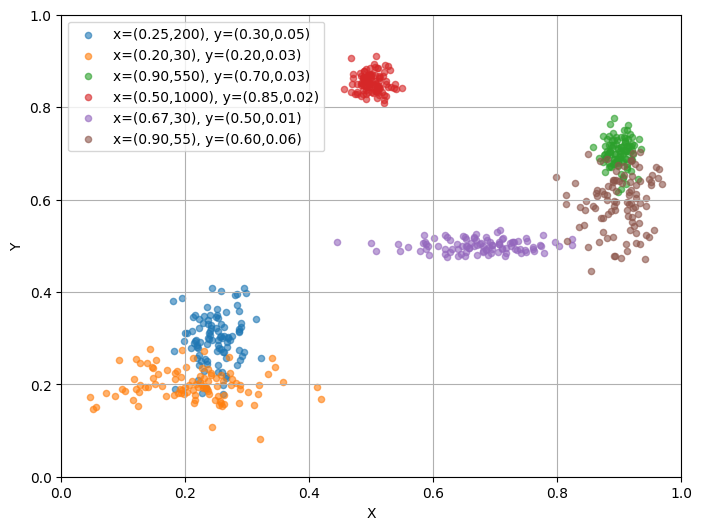

In [113]:
import numpy as np
import matplotlib.pyplot as plt

def beta_params(location, tightness):
    a = max(location * tightness, 1e-6)
    b = max((1 - location) * tightness, 1e-6)
    return a, b

# manually specify each cloud as:
# (x_location, x_tightness, y_center, y_std)
import random

def swap_y_values(specs, seed=None):
    rng = random.Random(seed)

    y_parts = [(y_center, y_std) for _, _, y_center, y_std in specs]
    rng.shuffle(y_parts)

    return [
        (x_loc, x_tight, y_center, y_std)
        for (x_loc, x_tight, _, _), (y_center, y_std) in zip(specs, y_parts)
    ]


specsMain = [
    (0.25, 200, 0.20, 0.03),
    (0.20,  30, 0.60, 0.06),
    (0.90, 550, 0.85, 0.02),
    (0.50,1000, 0.50, 0.015),
    (0.67,  30, 0.30, 0.05),
    (0.90,  55, 0.70, 0.03),
]
seed = random.randint(0, 10_000_000)
print("Seed:", seed)

# use this seed to get reproducible shuffling
# new_specs = shuffled_specs(specs, seed)
specs = swap_y_values(specsMain, seed)



# specs = [
#     (0.25, 200, 0.20, 0.03),
#     (0.20,  30, 0.30, 0.05),
#     (0.95, 550, 0.70, 0.03),
#     (0.50,1000, 0.50, 0.015),
#     (0.67,  30, 0.60, 0.06),
#     (0.90,  40, 0.85, 0.02)
# ]

n = 100
plt.figure(figsize=(8,6))

for x_loc, x_tight, y_center, y_std in specs:
    a = max(x_loc * x_tight, 1e-6)
    b = max((1 - x_loc) * x_tight, 1e-6)

    x = np.random.beta(a, b, n)
    y = np.random.normal(y_center, y_std, n)

    plt.scatter(
        x, y,
        s=20,
        alpha=0.6,
        label=f"x=({x_loc:.2f},{x_tight}), y=({y_center:.2f},{y_std:.2f})"
    )

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

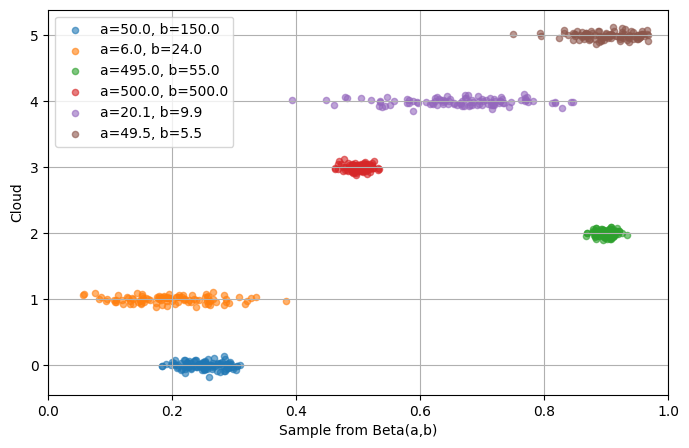

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def beta_params(location, tightness):
    """
    location: desired mean in [0,1]
    tightness: larger -> tighter distribution
    returns (a, b) for np.random.beta(a, b)
    """
    a = location * tightness
    b = (1 - location) * tightness

    # avoid invalid 0 values
    eps = 1e-6
    a = max(a, eps)
    b = max(b, eps)

    return a, b

# define clouds by (location, tightness)
specs = [
    (0.25, 200),
    (0.2, 30),
    (0.9, 550),
    (0.5, 1000),
    (0.67, 30),
    (0.9, 55),
]
params = [beta_params(loc, tight) for loc, tight in specs]


n = 100

plt.figure(figsize=(8,5))
itr=0
for i, (a, b) in enumerate(params):
    itr+=1
    x = np.random.beta(a, b, n)
    y = np.random.normal(i, 0.05, n)  # spread vertically so clouds do not overlap
    plt.scatter(
    x, y,
    s=20,
    alpha=0.6,
    label=f"NAS Algo {itr}"
)

plt.xlim(0, 1)
plt.yticks(range(len(params)))
plt.xlabel("Sample from Beta(a,b)")
plt.ylabel("Cloud")
plt.legend()
plt.grid(True)
plt.show()



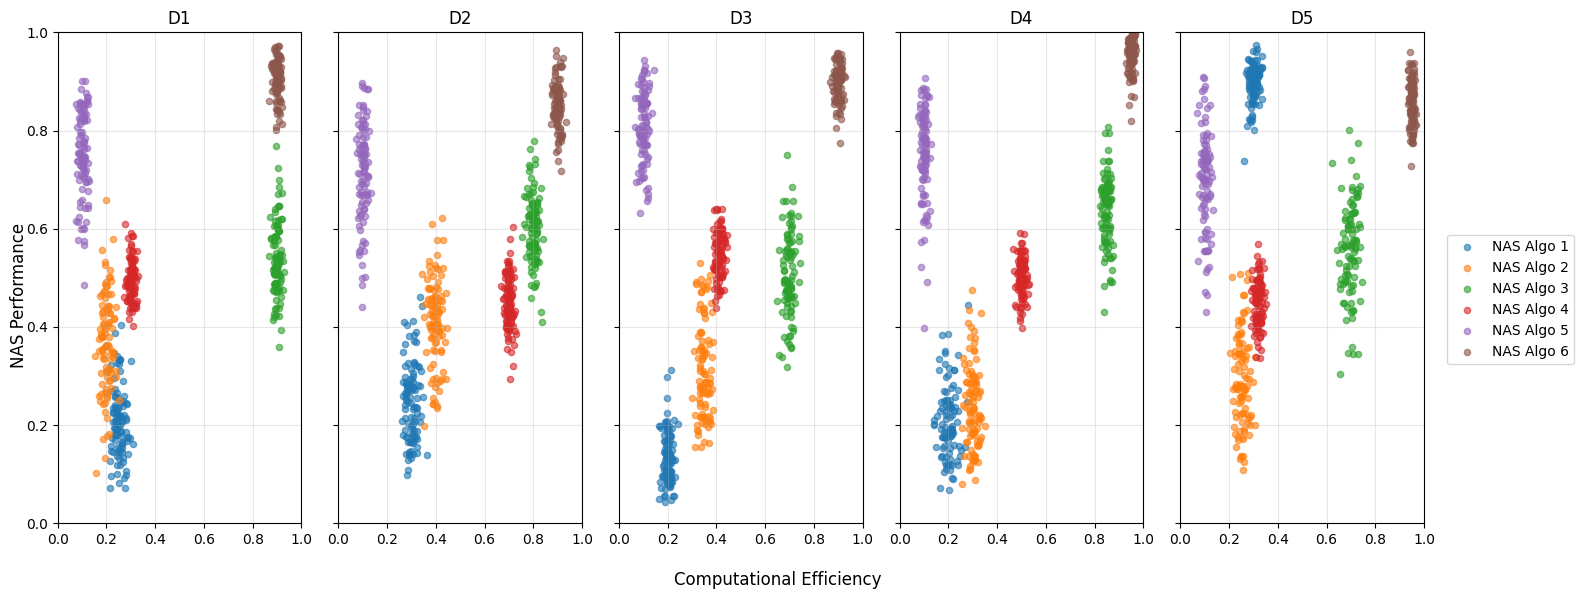

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def beta_params(location, tightness):
    a = max(location * tightness, 1e-6)
    b = max((1 - location) * tightness, 1e-6)
    return a, b

# X = Computational Efficiency
eff_specs = { 
    "D1": [(0.25,500),(0.20,500),(0.90,800),(0.30,1500),(0.10,600),(0.90,900)],
    "D2": [(0.30,500),(0.40,500),(0.80,700),(0.70,1500),(0.10,500),(0.90,700)],
    "D3": [(0.20,700),(0.35,700),(0.70,700),(0.41,1500),(0.10,500),(0.90,700)],
    "D4": [(0.20,200),(0.30,500),(0.85,900),(0.50,1500),(0.10,700),(0.95,500)],
    "D5": [(0.30,900),(0.25,500),(0.70,500),(0.32,1500),(0.10,500),(0.95,900)],
    }

# Y = NAS Performance
perf_specs = {
    "D1": [(0.20,30),(0.35,20),(0.55,40),(0.50,120),(0.75,25),(0.90,60)], 
    "D2": [(0.25,25),(0.40,30),(0.60,50),(0.45,100),(0.70,20),(0.85,50)], 
    "D3": [(0.15,40),(0.30,25),(0.50,35),(0.55,120),(0.80,30),(0.90,70)], 
    "D4": [(0.20,35),(0.25,30),(0.65,50),(0.50,150),(0.75,25),(0.95,40)], 
    "D5": [(0.90,60),(0.30,20),(0.55,30),(0.45,120),(0.70,20),(0.85,50)], 
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n = 100

fig, axes = plt.subplots(1, len(perf_specs), figsize=(16,6), sharex=True, sharey=True)

for ax, dataset_name in zip(axes, perf_specs.keys()):

    dataset_eff = eff_specs[dataset_name]
    dataset_perf = perf_specs[dataset_name]

    for algo_idx, ((x_loc, x_tight), (y_loc, y_tight)) in enumerate(zip(dataset_eff, dataset_perf)):

        a_x, b_x = beta_params(x_loc, x_tight)
        a_y, b_y = beta_params(y_loc, y_tight)

        x = np.random.beta(a_x, b_x, n)
        y = np.random.beta(a_y, b_y, n)

        ax.scatter(
            x, y,
            s=20,
            alpha=0.6,
            color=colors[algo_idx],
            label=f"NAS Algo {algo_idx+1}" if dataset_name == "D1" else None
        )

    ax.set_title(dataset_name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

fig.supxlabel("Computational Efficiency")
fig.supylabel("NAS Performance")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

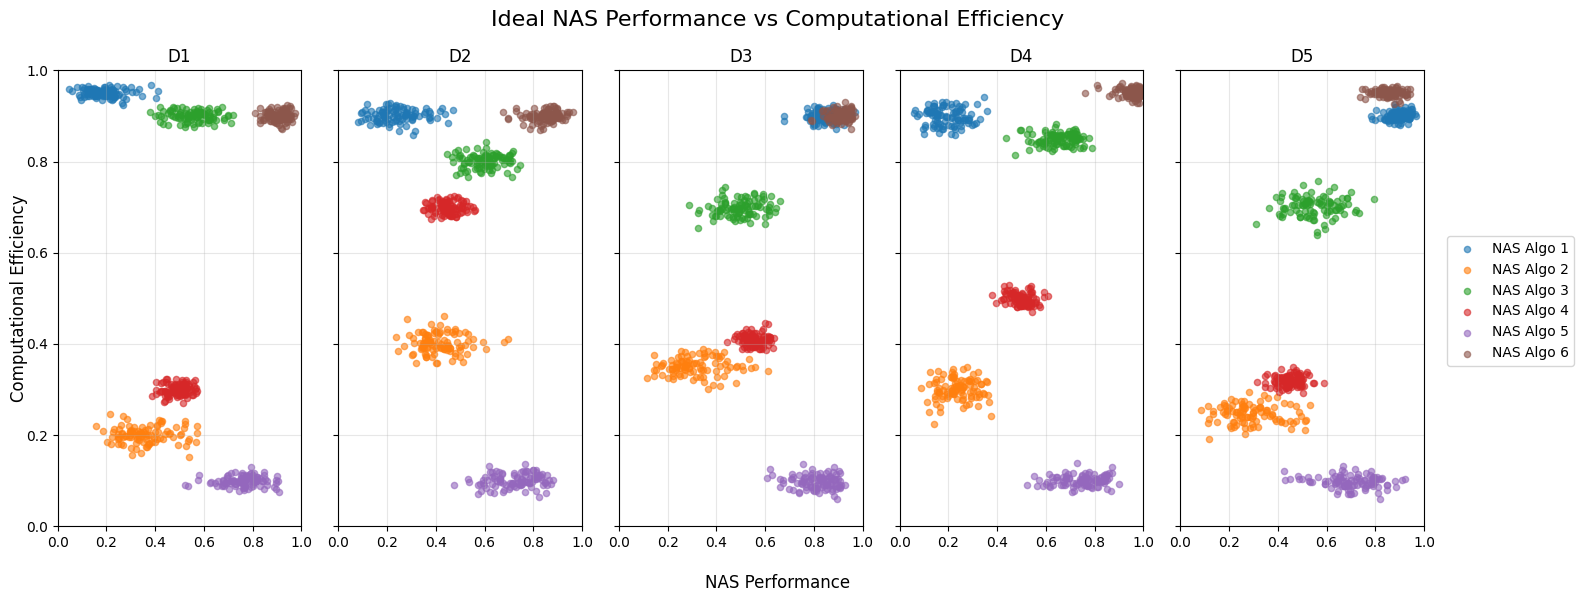

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def beta_params(location, tightness):
    a = max(location * tightness, 1e-6)
    b = max((1 - location) * tightness, 1e-6)
    return a, b

# Computational Efficiency specs
eff_specs = { 
    "D1": [(0.95,500),(0.20,500),(0.90,800),(0.30,1500),(0.10,600),(0.90,900)],
    "D2": [(0.90,500),(0.40,500),(0.80,700),(0.70,1500),(0.10,500),(0.90,700)],
    "D3": [(0.90,700),(0.35,700),(0.70,700),(0.41,1500),(0.10,500),(0.90,700)],
    "D4": [(0.90,200),(0.30,500),(0.85,900),(0.50,1500),(0.10,700),(0.95,500)],
    "D5": [(0.90,900),(0.25,500),(0.70,500),(0.32,1500),(0.10,500),(0.95,900)],
}

# NAS Performance specs
perf_specs = {
    "D1": [(0.20,30),(0.35,20),(0.55,40),(0.50,120),(0.75,25),(0.90,60)], 
    "D2": [(0.25,25),(0.40,30),(0.60,50),(0.45,100),(0.70,20),(0.85,50)], 
    "D3": [(0.85,40),(0.30,25),(0.50,35),(0.55,120),(0.80,30),(0.90,70)], 
    "D4": [(0.20,35),(0.25,30),(0.65,50),(0.50,150),(0.75,25),(0.95,40)], 
    "D5": [(0.90,60),(0.30,20),(0.55,30),(0.45,120),(0.70,20),(0.85,50)], 
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n = 100

fig, axes = plt.subplots(1, len(perf_specs), figsize=(16,6), sharex=True, sharey=True)

for ax, dataset_name in zip(axes, perf_specs.keys()):

    dataset_eff = eff_specs[dataset_name]
    dataset_perf = perf_specs[dataset_name]

    for algo_idx, ((eff_loc, eff_tight), (perf_loc, perf_tight)) in enumerate(zip(dataset_eff, dataset_perf)):

        a_perf, b_perf = beta_params(perf_loc, perf_tight)
        a_eff, b_eff = beta_params(eff_loc, eff_tight)

        # flipped: X is performance, Y is efficiency
        x = np.random.beta(a_perf, b_perf, n)
        y = np.random.beta(a_eff, b_eff, n)

        ax.scatter(
            x, y,
            s=20,
            alpha=0.6,
            color=colors[algo_idx],
            label=f"NAS Algo {algo_idx+1}" if dataset_name == "D1" else None
        )

    ax.set_title(dataset_name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

fig.supxlabel("NAS Performance")
fig.supylabel("Computational Efficiency")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

# plt.tight_layout(rect=[0, 0, 0.92, 1])



fig.suptitle("Ideal NAS Performance vs Computational Efficiency", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

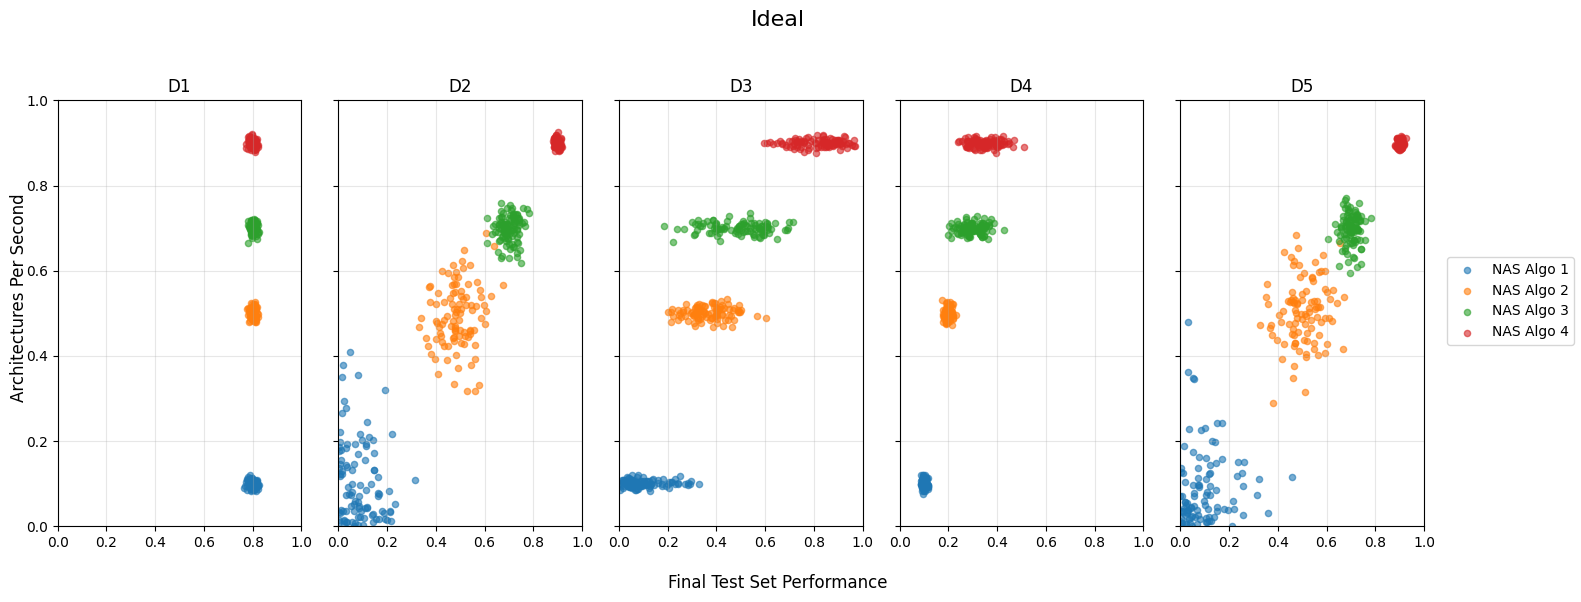

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def beta_params(location, tightness):
    a = max(location * tightness, 1e-6)
    b = max((1 - location) * tightness, 1e-6)
    return a, b

# Computational Efficiency specs
# eff_specs = { 
#     "D1": [(0.1,1500),(0.2,1500),(0.3,1500),(0.6,1500),(0.5,1500),(0.6,1500)],
#     "D2": [(0.1,1500),(0.2,1500),(0.3,1500),(0.6,1500),(0.5,1500),(0.6,1500)],
#     "D3": [(0.1,1500),(0.2,1500),(0.3,1500),(0.6,1500),(0.5,1500),(0.6,1500)],
#     "D4": [(0.1,1500),(0.2,1500),(0.3,1500),(0.6,1500),(0.5,1500),(0.6,1500)],
#     "D5": [(0.1,1500),(0.2,1500),(0.3,1500),(0.6,1500),(0.5,1500),(0.6,1500)],
# }

# # NAS Performance specs
# perf_specs = {
#     "D1": [(0.85,1500),(0.8,100),(0.65,50),(0.8,40),(0.2,1500),(0.1,1500)], 
#     "D2": [(0.85,100),(0.8,100),(0.65,1000),(0.1,20),(0.2,1500),(0.1,1500)], 
#     "D3": [(0.75,50),(0.8,50),(0.75,50),(0.1,4),(0.2,1500),(0.1,1500)], 
#     "D4": [(0.8,30),(0.8,1500),(0.65,15),(0.1,40),(0.2,1500),(0.1,1500)], 
#     "D5": [(0.9,1500),(0.8,1500),(0.65,1500),(0.1,40),(0.2,1500),(0.1,1500)], 
# }
eff_specs = { 
    "D1": [(0.1,1500),(0.5,1500),(0.7,1500),(0.9,1500),(0.1,1500),(0.1,1500)],
    "D2": [(0.10,10),(0.50,50),(0.70,200),(0.90,1500),(0.90,1500),(0.90,1500)],
    "D3": [(0.1,1500),(0.5,1500),(0.7,1500),(0.9,1500),(0.1,1500),(0.1,1500)],
    "D4": [(0.1,1500),(0.5,1500),(0.7,1500),(0.9,1500),(0.1,1500),(0.1,1500)],
    "D5": [(0.10,10),(0.50,50),(0.70,200),(0.90,1500),(0.90,1500),(0.90,1500)], 
}

# NAS Performance specs
perf_specs = {
    "D1": [(0.80,1500),(0.80,1500),(0.80,1500),(0.80,1500),(0.90,1500),(0.90,1500)], 
    "D2": [(0.10,10),(0.50,50),(0.70,200),(0.90,1500),(0.90,1500),(0.90,1500)],  
    "D3": [(0.10,15),(0.35,35),(0.50,15),(0.8,15),(0.90,1500),(0.90,1500)], 
    "D4": [(0.10,1500),(0.20,1500),(0.30,100),(0.350,100),(0.90,1500),(0.90,1500)], 
    "D5": [(0.10,10),(0.50,50),(0.70,200),(0.90,1500),(0.90,1500),(0.90,1500)], 
}
# Keep only first 4 algorithms in each dataset
eff_specs = {k: v[:4] for k, v in eff_specs.items()}
perf_specs = {k: v[:4] for k, v in perf_specs.items()}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n = 100

fig, axes = plt.subplots(1, len(perf_specs), figsize=(16,6), sharex=True, sharey=True)

for ax, dataset_name in zip(axes, perf_specs.keys()):

    dataset_eff = eff_specs[dataset_name]
    dataset_perf = perf_specs[dataset_name]

    for algo_idx, ((eff_loc, eff_tight), (perf_loc, perf_tight)) in enumerate(zip(dataset_eff, dataset_perf)):

        a_perf, b_perf = beta_params(perf_loc, perf_tight)
        a_eff, b_eff = beta_params(eff_loc, eff_tight)

        x = np.random.beta(a_perf, b_perf, n)   # NAS Performance
        y = np.random.beta(a_eff, b_eff, n)     # Computational Efficiency

        ax.scatter(
            x, y,
            s=20,
            alpha=0.6,
            color=colors[algo_idx],
            label=f"NAS Algo {algo_idx+1}" if dataset_name == "D1" else None
        )

    ax.set_title(dataset_name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

fig.supxlabel("Final Test Set Performance")
fig.supylabel("Architectures Per Second")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

fig.suptitle("Easy", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()


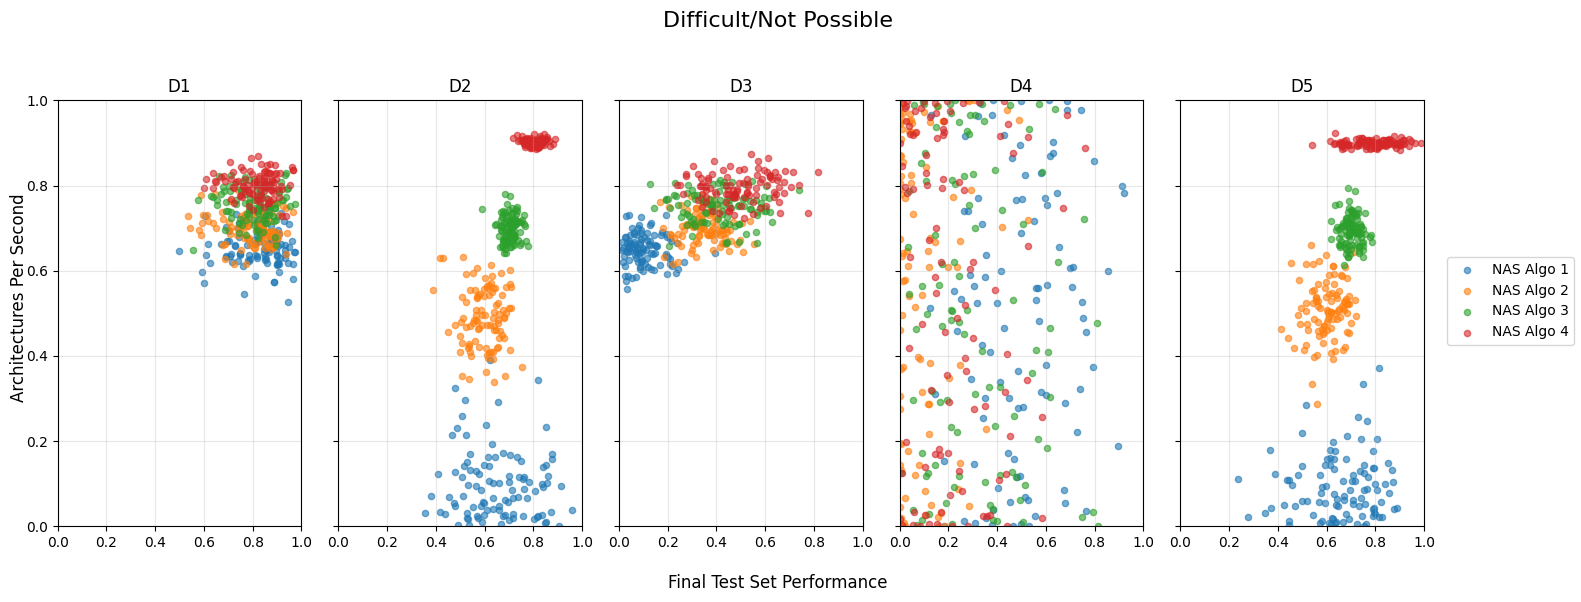

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def beta_params(location, tightness):
    a = max(location * tightness, 1e-6)
    b = max((1 - location) * tightness, 1e-6)
    return a, b

eff_specs = { 
    "D1": [(0.65,150),(0.7,150),(0.75,150),(0.8,150),(0.1,1500),(0.1,1500)],
    "D2": [(0.10,10),(0.50,50),(0.70,200),(0.90,1500),(0.90,1500),(0.90,1500)],
    "D3": [(0.65,150),(0.7,150),(0.75,150),(0.8,150),(0.1,1500),(0.1,1500)],
    "D4": [(0.5,1),(0.5,1),(0.5,1),(0.5,1),(0.90,1500),(0.90,1500)], 
    "D5": [(0.10,10),(0.50,50),(0.70,200),(0.90,1500),(0.90,1500),(0.90,1500)],
}

# NAS Performance specs
perf_specs = {
    "D1": [(0.80,15),(0.80,15),(0.80,15),(0.80,15),(0.90,1500),(0.90,1500)], 
    "D2": [(0.65,10),(0.60,50),(0.70,200),(0.80,150),(0.90,1500),(0.90,1500)],
    "D3": [(0.10,15),(0.35,35),(0.40,15),(0.5,15),(0.90,1500),(0.90,1500)], 
    "D4": [(0.5,5),(0.10,5),(0.3,5),(0.2,5),(0.90,1500),(0.90,1500)], 
    "D5": [(0.65,10),(0.60,50),(0.70,200),(0.80,15),(0.90,1500),(0.90,1500)],
}
# Keep only first 4 algorithms in each dataset
eff_specs = {k: v[:4] for k, v in eff_specs.items()}
perf_specs = {k: v[:4] for k, v in perf_specs.items()}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
n = 100

fig, axes = plt.subplots(1, len(perf_specs), figsize=(16,6), sharex=True, sharey=True)

for ax, dataset_name in zip(axes, perf_specs.keys()):

    dataset_eff = eff_specs[dataset_name]
    dataset_perf = perf_specs[dataset_name]

    for algo_idx, ((eff_loc, eff_tight), (perf_loc, perf_tight)) in enumerate(zip(dataset_eff, dataset_perf)):

        a_perf, b_perf = beta_params(perf_loc, perf_tight)
        a_eff, b_eff = beta_params(eff_loc, eff_tight)

        x = np.random.beta(a_perf, b_perf, n)   # NAS Performance
        y = np.random.beta(a_eff, b_eff, n)     # Computational Efficiency

        ax.scatter(
            x, y,
            s=20,
            alpha=0.6,
            color=colors[algo_idx],
            label=f"NAS Algo {algo_idx+1}" if dataset_name == "D1" else None
        )

    ax.set_title(dataset_name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

fig.supxlabel("Final Test Set Performance")
fig.supylabel("Architectures Per Second")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

fig.suptitle("Difficult/Not Possible", fontsize=16)

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()